In [ ]:
## Directory structure and file count script
import os

path = '/media/ulises-calderon/SteamDisk/Recuperacion/Escuela/8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/src'
#List folders and files in the directory
global_count = 0
for item in os.listdir(path):
    inner_items = os.listdir(os.path.join(path, item))
    print(item)
    for inner_item in inner_items:
        print(f"  {inner_item}")
        count = 0
        for sub_item in os.listdir(os.path.join(path, item, inner_item)):
            count += 1
        print(f"  {inner_item}: {count}")
        global_count += count

print(f"Total number of files: {global_count}")

garbage_classification
  battery
  battery: 1889
  biological
  biological: 1982
  cardboard
  cardboard: 2328
  clothes
  clothes: 2106
  glass
  glass: 2011
  metal
  metal: 1789
  paper
  paper: 2310
  plastic
  plastic: 1993
  shoes
  shoes: 1977
  trash
  trash: 1644
Total number of files: 20029


In [ ]:
import os
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import concurrent.futures
import warnings
warnings.filterwarnings('ignore')

# ── Rutas ────────────────────────────────────────────────────────────────────
SRC_PATH = Path('/media/ulises-calderon/SteamDisk/Recuperacion/Escuela/'
                '8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/'
                'src/garbage_classification')

DST_PATH = Path('/media/ulises-calderon/SteamDisk/Recuperacion/Escuela/'
                '8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/'
                'src/local_test')

# ── Hiperparámetros de preprocesamiento ──────────────────────────────────────
IMG_SIZE    = (300, 300)   # EfficientNetB3 native input
JPEG_Q      = 95           # calidad JPEG de salida 
CLAHE_CL    = 2.0          # clipLimit CLAHE (2.0 = conservador, no agresivo)
CLAHE_GRID  = (8, 8)       # tileGridSize CLAHE 
N_WORKERS   = 8            # hilos paralelos (ajusta a tus núcleos lógicos)

DST_PATH.mkdir(parents=True, exist_ok=True)
print(f'Fuente  : {SRC_PATH}')
print(f'Destino : {DST_PATH}')
print(f'Tamaño  : {IMG_SIZE}  |  CLAHE clip={CLAHE_CL}  grid={CLAHE_GRID}')

Fuente  : /media/ulises-calderon/SteamDisk/Recuperacion/Escuela/8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/src/garbage_classification
Destino : /media/ulises-calderon/SteamDisk/Recuperacion/Escuela/8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/src/local_test
Tamaño  : (300, 300)  |  CLAHE clip=2.0  grid=(8, 8)


In [9]:
def apply_clahe(bgr_img: np.ndarray,
                clip_limit: float = CLAHE_CL,
                tile_grid: tuple  = CLAHE_GRID) -> np.ndarray:
    """
    Aplica CLAHE en el canal L del espacio LAB.
    Mejora el contraste local sin afectar la crominancia,
    lo que beneficia clases oscuras/opacas (trash, metal).
    """
    lab   = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    l_eq  = clahe.apply(l)
    lab_eq = cv2.merge([l_eq, a, b])
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)


def preprocess_image(src_fp: Path, dst_fp: Path) -> str:
    """
    Procesa una imagen individual:
      1. Abre con PIL → convierte a RGB (maneja RGBA, L, P, etc.)
      2. Resize con LANCZOS (alta calidad, sin aliasing)
      3. Convierte a BGR para OpenCV → aplica CLAHE
      4. Guarda como JPEG q=95 en la ruta destino
    Retorna 'ok' o el mensaje de error.
    """
    try:
        # 1. Abrir y forzar RGB
        pil_img = Image.open(src_fp).convert('RGB')

        # 2. Resize con LANCZOS (mejor para downscale)
        pil_img = pil_img.resize(IMG_SIZE, Image.LANCZOS)

        # 3. PIL (RGB) → NumPy → BGR para OpenCV
        bgr = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

        # 4. CLAHE sobre canal L en LAB
        bgr_eq = apply_clahe(bgr)

        # 5. Guardar como JPEG
        dst_fp.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(dst_fp), bgr_eq,
                    [cv2.IMWRITE_JPEG_QUALITY, JPEG_Q])
        return 'ok'

    except Exception as e:
        return f'ERROR: {src_fp.name} → {e}'


print('✓ Funciones de preprocesamiento definidas')

✓ Funciones de preprocesamiento definidas


In [11]:
# ── Construir lista de tareas (src, dst) ─────────────────────────────────────
tasks = []
VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}

for cls_dir in sorted(SRC_PATH.iterdir()):
    if not cls_dir.is_dir():
        continue
    dst_cls = DST_PATH / cls_dir.name
    for fp in cls_dir.iterdir():
        if fp.suffix.lower() in VALID_EXT:
            dst_fp = dst_cls / (fp.stem + '.jpg')  # siempre .jpg en destino
            tasks.append((fp, dst_fp))

print(f'Total imágenes a procesar: {len(tasks):,}')

# ── Procesamiento paralelo con ThreadPoolExecutor ────────────────────────────
errors = []

with concurrent.futures.ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(preprocess_image, src, dst): (src, dst)
               for src, dst in tasks}

    for future in concurrent.futures.as_completed(futures):
        result = future.result()
        if result != 'ok':
            errors.append(result)

print(f'\nCompletado — {len(tasks)-len(errors):,} imágenes procesadas')
if errors:
    print(f'⚠  {len(errors)} errores:')
    for e in errors[:10]:
        print(f'   {e}')

Total imágenes a procesar: 20,029

Completado — 20,029 imágenes procesadas


In [15]:
# ── Verificación post-proceso ─────────────────────────────────────────────────
import pandas as pd

verify = {}
for cls_dir in sorted(DST_PATH.iterdir()):
    if cls_dir.is_dir():
        verify[cls_dir.name] = len(list(cls_dir.glob('*.jpg')))

vdf = pd.DataFrame({'class': list(verify.keys()),
                    'processed': list(verify.values())})
vdf['original'] = vdf['class'].map(
    {cls_dir.name: len(list(cls_dir.glob('*')))
     for cls_dir in SRC_PATH.iterdir() if cls_dir.is_dir()}
)
vdf['match'] = vdf['processed'] == vdf['original']

print(vdf.to_string(index=False))
print(f'\nTotal procesadas : {vdf["processed"].sum():,}')
print(f'Total originales : {vdf["original"].sum():,}')
print(f'Clases OK        : {vdf["match"].sum()} | {len(vdf)}')

     class  processed  original  match
   battery       1889      1889   True
biological       1982      1982   True
 cardboard       2328      2328   True
   clothes       2106      2106   True
     glass       2011      2011   True
     metal       1785      1789  False
     paper       2310      2310   True
   plastic       1993      1993   True
     shoes       1977      1977   True
     trash       1636      1644  False

Total procesadas : 20,017
Total originales : 20,029
Clases OK        : 8 | 10


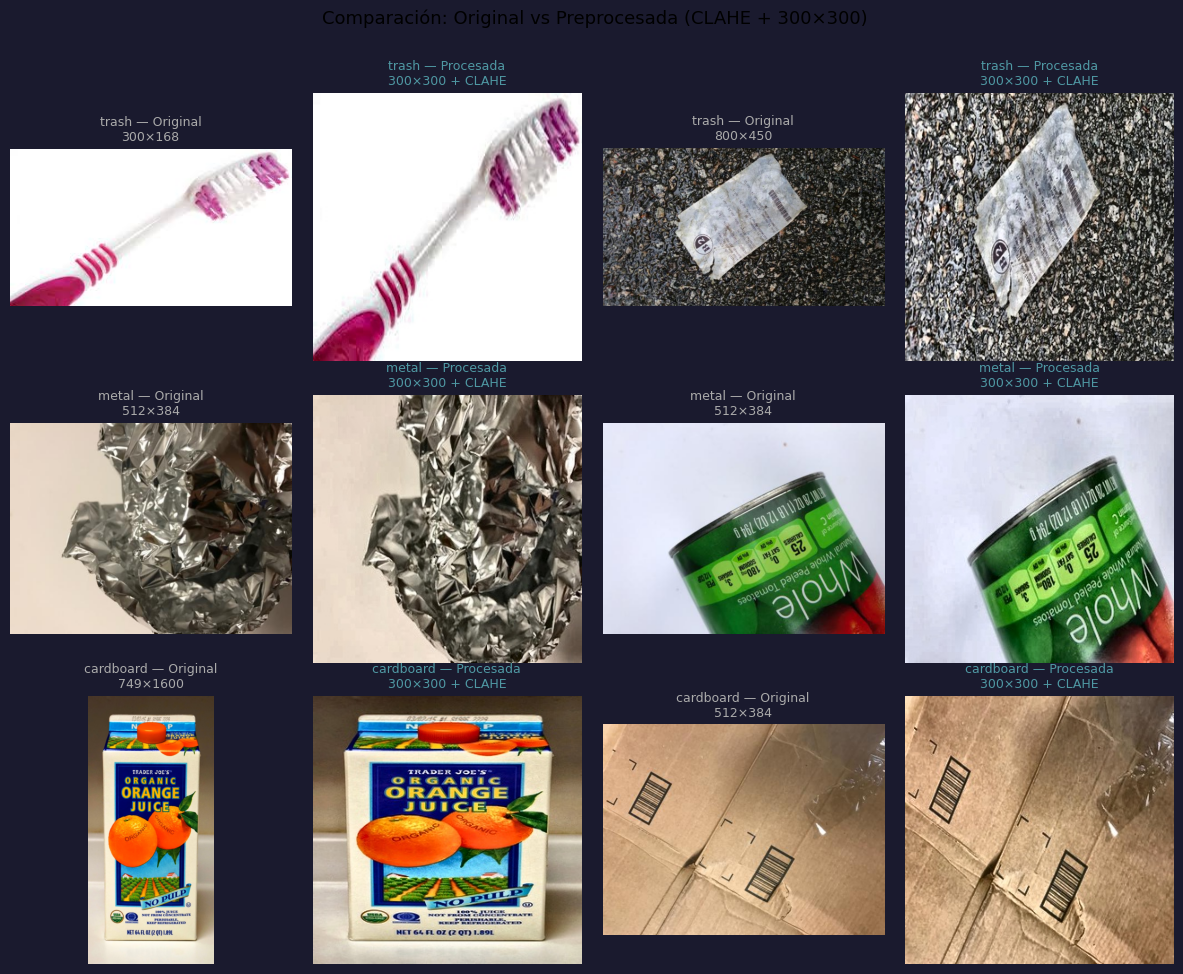

In [18]:
# ── Comparación visual: original vs procesada (3 clases, 2 ejemplos) ─────────
import random, matplotlib.pyplot as plt

SHOW_CLASSES = ['trash', 'metal', 'cardboard']  # clases interesantes
N_EXAMPLES   = 2

fig, axes = plt.subplots(len(SHOW_CLASSES), N_EXAMPLES * 2,
                         figsize=(N_EXAMPLES * 6, len(SHOW_CLASSES) * 3.2))
fig.patch.set_facecolor('#1a1a2e')

for row, cls in enumerate(SHOW_CLASSES):
    src_files = list((SRC_PATH / cls).iterdir())
    samples   = random.sample(src_files, N_EXAMPLES)

    for col, src_fp in enumerate(samples):
        dst_fp = DST_PATH / cls / (src_fp.stem + '.jpg')

        orig = Image.open(src_fp).convert('RGB')
        proc = Image.open(dst_fp).convert('RGB')

        ax_orig = axes[row][col * 2]
        ax_proc = axes[row][col * 2 + 1]

        ax_orig.imshow(orig)
        ax_orig.set_title(f'{cls} — Original\n{orig.size[0]}×{orig.size[1]}',
                          fontsize=9, color='#aaa')
        ax_orig.axis('off')

        ax_proc.imshow(proc)
        ax_proc.set_title(f'{cls} — Procesada\n300×300 + CLAHE',
                          fontsize=9, color='#4f98a3')
        ax_proc.axis('off')

fig.suptitle('Comparación: Original vs Preprocesada (CLAHE + 300×300)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# ── Split: Train / Validation / Test  (70 / 15 / 15) ─────────────────────────
import os, shutil, random
from pathlib import Path
from sklearn.model_selection import train_test_split
import pandas as pd

SRC_PATH = Path('/media/ulises-calderon/SteamDisk/Recuperacion/Escuela/'
                '8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/'
                'src/local_test')

DST_PATH = Path('/media/ulises-calderon/SteamDisk/Recuperacion/Escuela/'
                '8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/'
                'src/split_data')

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15   # del total; test = 1 - 0.70 - 0.15 = 0.15
SEED        = 42
random.seed(SEED)

# Crear estructura de carpetas destino
for split in ('train', 'val', 'test'):
    for cls_dir in sorted(SRC_PATH.iterdir()):
        if cls_dir.is_dir():
            (DST_PATH / split / cls_dir.name).mkdir(parents=True, exist_ok=True)

# ── Split por clase (estratificado implícitamente al hacerlo clase por clase) ─
summary = []

for cls_dir in sorted(SRC_PATH.iterdir()):
    if not cls_dir.is_dir():
        continue

    files = sorted(cls_dir.glob('*.jpg'))
    random.shuffle(files)          # shuffle antes de partir

    # Primer corte: train vs (val+test)
    train_files, temp_files = train_test_split(
        files, train_size=TRAIN_RATIO, random_state=SEED)

    # Segundo corte: val vs test  (50/50 del 30% restante → 15% cada uno)
    val_files, test_files = train_test_split(
        temp_files, test_size=0.5, random_state=SEED)

    # Copiar archivos
    for split_name, split_files in [('train', train_files),
                                     ('val',   val_files),
                                     ('test',  test_files)]:
        for fp in split_files:
            shutil.copy2(fp, DST_PATH / split_name / cls_dir.name / fp.name)

    summary.append({
        'class':  cls_dir.name,
        'total':  len(files),
        'train':  len(train_files),
        'val':    len(val_files),
        'test':   len(test_files),
    })

# ── Reporte ───────────────────────────────────────────────────────────────────
df_split = pd.DataFrame(summary)
df_split['train%'] = (df_split['train'] / df_split['total'] * 100).round(1)
df_split['val%']   = (df_split['val']   / df_split['total'] * 100).round(1)
df_split['test%']  = (df_split['test']  / df_split['total'] * 100).round(1)

print(df_split.to_string(index=False))
print(f"\nTotales  →  train: {df_split['train'].sum():,}"
      f"  |  val: {df_split['val'].sum():,}"
      f"  |  test: {df_split['test'].sum():,}"
      f"  |  total: {df_split['total'].sum():,}")

     class  total  train  val  test  train%  val%  test%
   battery   1889   1322  283   284    70.0  15.0   15.0
biological   1982   1387  297   298    70.0  15.0   15.0
 cardboard   2328   1629  349   350    70.0  15.0   15.0
   clothes   2106   1474  316   316    70.0  15.0   15.0
     glass   2011   1407  302   302    70.0  15.0   15.0
     metal   1785   1249  268   268    70.0  15.0   15.0
     paper   2310   1617  346   347    70.0  15.0   15.0
   plastic   1993   1395  299   299    70.0  15.0   15.0
     shoes   1977   1383  297   297    70.0  15.0   15.0
     trash   1636   1145  245   246    70.0  15.0   15.0

Totales  →  train: 14,008  |  val: 3,002  |  test: 3,007  |  total: 20,017


In [23]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import timm
from timm.data import resolve_data_config, transforms_factory
from torchmetrics import Accuracy, F1Score, ConfusionMatrix

# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False   # True si tamaño de batch es fijo

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando : {DEVICE}  ({torch.cuda.get_device_name(0)})")

# ── Rutas ─────────────────────────────────────────────────────────────────────
DATA_PATH = Path('/media/ulises-calderon/SteamDisk/Recuperacion/Escuela/'
                 '8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/'
                 'src/split_data')

# ── Hiperparámetros ───────────────────────────────────────────────────────────
IMG_SIZE    = 300        # EfficientNetB3 native
BATCH_SIZE  = 32         # seguro para RTX 2070 8 GB con 300×300
NUM_EPOCHS  = 20
LR_HEAD     = 1e-3       # learning rate para la cabeza nueva
LR_FINETUNE = 1e-4       # lr para fine-tuning del backbone (fase 2)
WEIGHT_DECAY= 1e-4
NUM_CLASSES = 10
PATIENCE    = 5          # early stopping

Usando : cuda  (NVIDIA GeForce RTX 2070 with Max-Q Design)


In [ ]:
# ── Transforms ────────────────────────────────────────────────────────────────
# EfficientNetB3 fue entrenado con estos stats de ImageNet
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, #
                           saturation=0.15, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # ligera distorsión geométrica
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
train_ds = datasets.ImageFolder(DATA_PATH / 'train', transform=train_tf)
val_ds   = datasets.ImageFolder(DATA_PATH / 'val',   transform=val_test_tf)
test_ds  = datasets.ImageFolder(DATA_PATH / 'test',  transform=val_test_tf)

CLASS_NAMES = train_ds.classes
print(f"Clases ({len(CLASS_NAMES)}): {CLASS_NAMES}")
print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}")

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=6,
                          pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4,
                          pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=4,
                          pin_memory=True, persistent_workers=True)

print(f"Batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Clases (10): ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Train: 14,008  |  Val: 3,002  |  Test: 3,007
Batches — train: 438  val: 94  test: 94


In [25]:
# ── Class weights (compensa trash y metal sub-representados) ──────────────────
counts     = np.array([len(list((DATA_PATH / 'train' / c).glob('*.jpg')))
                       for c in CLASS_NAMES])
class_wts  = torch.tensor(counts.max() / counts, dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(CLASS_NAMES, class_wts.cpu().numpy().round(3))))

# ── Modelo: EfficientNetB3 con cabeza nueva ───────────────────────────────────
model = timm.create_model(
    'efficientnet_b3',
    pretrained=True,          # descarga pesos ImageNet (~48 MB)
    num_classes=NUM_CLASSES
)

# Fase 1: congela backbone, solo entrena la cabeza
for name, param in model.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,}")

# ── Loss y optimizador (Fase 1) ───────────────────────────────────────────────
criterion  = nn.CrossEntropyLoss(weight=class_wts)
optimizer  = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=WEIGHT_DECAY
)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

print("✓ Modelo listo — Fase 1: solo cabeza")

Class weights: {'battery': np.float32(1.232), 'biological': np.float32(1.174), 'cardboard': np.float32(1.0), 'clothes': np.float32(1.105), 'glass': np.float32(1.158), 'metal': np.float32(1.304), 'paper': np.float32(1.007), 'plastic': np.float32(1.168), 'shoes': np.float32(1.178), 'trash': np.float32(1.423)}


Parámetros entrenables: 15,370 / 10,711,602
✓ Modelo listo — Fase 1: solo cabeza


In [26]:
def run_epoch(loader, model, criterion, optimizer, is_train: bool):
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type='cuda', dtype=torch.float16):
                outputs = model(imgs)
                loss    = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            correct    += outputs.argmax(dim=1).eq(labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total

In [27]:
from copy import deepcopy

EPOCHS_PHASE1 = 5    # cabeza solamente
EPOCHS_PHASE2 = 20   # fine-tuning completo
PATIENCE      = 6    # early stopping

history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [],
           'phase': []}

best_val_loss = float('inf')
best_weights  = None
patience_cnt  = 0

CKPT_PATH = Path('/media/ulises-calderon/SteamDisk/Recuperacion/Escuela/'
                 '8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/'
                 'src/best_efficientnetb3.pth')

# ═══════════════════════════════════════════════════════════════
# FASE 1 — solo cabeza  (backbone congelado)
# ═══════════════════════════════════════════════════════════════
print("=" * 55)
print("FASE 1 — Head only  (backbone congelado)")
print("=" * 55)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer, is_train=True)
    va_loss, va_acc = run_epoch(val_loader,   model, criterion, optimizer, is_train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['phase'].append(1)

    print(f"[P1 E{epoch:02d}/{EPOCHS_PHASE1}]  "
          f"loss {tr_loss:.4f}/{va_loss:.4f}  "
          f"acc {tr_acc:.3f}/{va_acc:.3f}  "
          f"({time.time()-t0:.1f}s)")

# ═══════════════════════════════════════════════════════════════
# FASE 2 — fine-tuning completo  (descongelar backbone)
# ═══════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("FASE 2 — Fine-tuning completo  (backbone descongelado)")
print("=" * 55)

# Descongelar todos los parámetros
for param in model.parameters():
    param.requires_grad = True

# Optimizer con LR diferencial: backbone más lento que la cabeza
optimizer = optim.AdamW([
    {'params': [p for n, p in model.named_parameters()
                if 'classifier' not in n],  'lr': LR_FINETUNE},
    {'params': [p for n, p in model.named_parameters()
                if 'classifier' in n],      'lr': LR_HEAD},
], weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS_PHASE2, eta_min=1e-7
)

for epoch in range(1, EPOCHS_PHASE2 + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer, is_train=True)
    va_loss, va_acc = run_epoch(val_loader,   model, criterion, optimizer, is_train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['phase'].append(2)

    # ── Guardar mejor modelo ──────────────────────────────────
    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_weights  = deepcopy(model.state_dict())
        torch.save(best_weights, CKPT_PATH)
        tag = ' ←  best'
        patience_cnt = 0
    else:
        patience_cnt += 1
        tag = f' (patience {patience_cnt}/{PATIENCE})'

    print(f"[P2 E{epoch:02d}/{EPOCHS_PHASE2}]  "
          f"loss {tr_loss:.4f}/{va_loss:.4f}  "
          f"acc {tr_acc:.3f}/{va_acc:.3f}  "
          f"({time.time()-t0:.1f}s){tag}")

    # ── Early stopping ────────────────────────────────────────
    if patience_cnt >= PATIENCE:
        print(f"\n⏹ Early stopping en época {EPOCHS_PHASE2 - (PATIENCE - epoch)}")
        break

# Restaurar mejor estado
model.load_state_dict(best_weights)
print(f"\n Entrenamiento completo — mejor val_loss: {best_val_loss:.4f}")
print(f"   Checkpoint guardado en: {CKPT_PATH}")

FASE 1 — Head only  (backbone congelado)
[P1 E01/5]  loss 1.1813/nan  acc 0.629/0.803  (63.1s)
[P1 E02/5]  loss 0.5375/0.4980  acc 0.823/0.860  (50.1s)
[P1 E03/5]  loss 0.4361/0.3959  acc 0.857/0.885  (52.7s)
[P1 E04/5]  loss 0.3856/0.3406  acc 0.874/0.896  (111.3s)
[P1 E05/5]  loss 0.3486/nan  acc 0.886/0.904  (53.7s)

FASE 2 — Fine-tuning completo  (backbone descongelado)
[P2 E01/20]  loss 0.2281/0.1500  acc 0.927/0.955  (262.4s) ←  best
[P2 E02/20]  loss 0.0842/0.1080  acc 0.972/0.968  (211.8s) ←  best
[P2 E03/20]  loss 0.0557/0.2579  acc 0.981/0.967  (225.5s) (patience 1/6)
[P2 E04/20]  loss 0.0317/0.1097  acc 0.990/0.971  (247.9s) (patience 2/6)
[P2 E05/20]  loss 0.0259/0.0887  acc 0.991/0.977  (237.8s) ←  best
[P2 E06/20]  loss 0.0196/0.0971  acc 0.995/0.975  (196.7s) (patience 1/6)
[P2 E07/20]  loss 0.0150/0.1004  acc 0.995/0.973  (245.7s) (patience 2/6)
[P2 E08/20]  loss 0.0123/0.0909  acc 0.996/0.978  (250.9s) (patience 3/6)
[P2 E09/20]  loss 0.0115/0.0920  acc 0.997/0.979  (1

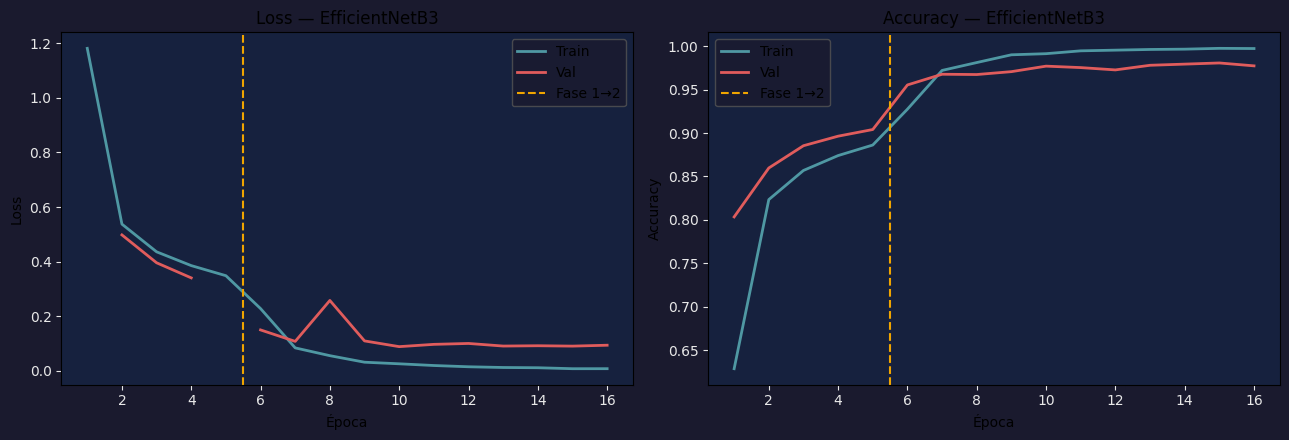

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#1a1a2e')
TEAL = '#4f98a3'; RED = '#e05c5c'; AMBER = '#f0a500'

epochs_x = range(1, len(history['train_loss']) + 1)
split_ep  = EPOCHS_PHASE1 + 0.5  # línea divisoria entre fases

for ax, metric, title in zip(
        axes,
        [('train_loss', 'val_loss'), ('train_acc', 'val_acc')],
        ['Loss',                      'Accuracy']):

    ax.plot(epochs_x, history[metric[0]], color=TEAL,  label='Train', linewidth=2)
    ax.plot(epochs_x, history[metric[1]], color=RED,   label='Val',   linewidth=2)
    ax.axvline(split_ep, color=AMBER, linestyle='--', linewidth=1.5, label='Fase 1→2')
    ax.set_xlabel('Época'); ax.set_ylabel(title)
    ax.set_title(f'{title} — EfficientNetB3', fontsize=12)
    ax.legend(fontsize=10, facecolor='#1a1a2e', edgecolor='#555')
    ax.set_facecolor('#16213e')
    ax.tick_params(colors='#e8e8e8')

plt.tight_layout()
plt.show()

REPORTE DE CLASIFICACIÓN — Test set
              precision    recall  f1-score   support

     battery     0.9861    0.9965    0.9912       284
  biological     1.0000    0.9966    0.9983       298
   cardboard     0.9747    0.9914    0.9830       350
     clothes     0.9968    0.9968    0.9968       316
       glass     0.9608    0.9735    0.9671       302
       metal     0.9814    0.9851    0.9832       268
       paper     0.9941    0.9741    0.9840       347
     plastic     0.9761    0.9565    0.9662       299
       shoes     0.9704    0.9933    0.9817       297
       trash     0.9958    0.9675    0.9814       246

    accuracy                         0.9834      3007
   macro avg     0.9836    0.9831    0.9833      3007
weighted avg     0.9835    0.9834    0.9834      3007



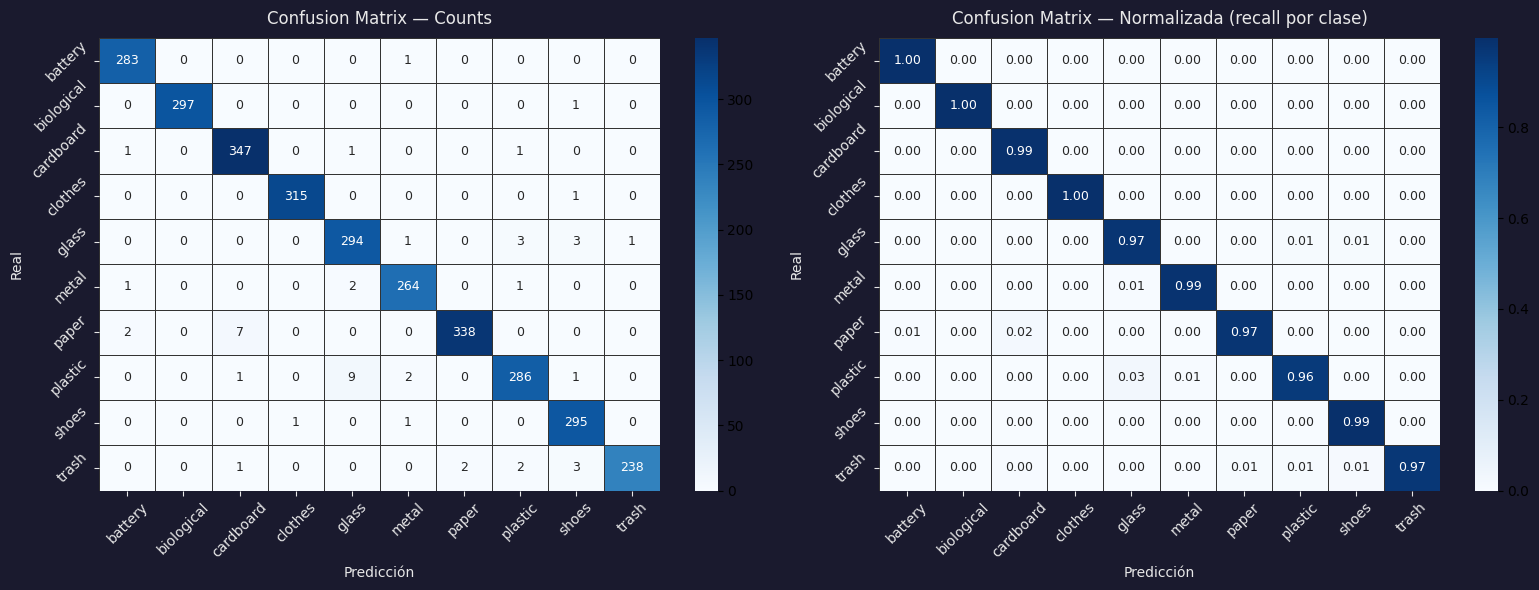


=== Clases con mayor confusión (off-diagonal > 5%) ===

RESUMEN EJECUTIVO
  Accuracy          : 98.34%
  F1 Macro          : 0.9833
  F1 Weighted       : 0.9834
  Imágenes test     : 3,007
  Modelo guardado   : /media/ulises-calderon/SteamDisk/Recuperacion/Escuela/8vo Semestre/ComputoEnLaNube/aws_cloud_implementation/src/best_efficientnetb3.pth

→ Siguiente paso: exportar a TorchScript / ONNX para SageMaker


In [30]:
# ── Métricas finales sobre Test set ───────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
!pip install seaborn --quiet
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            outputs = model(imgs)
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── Classification report ─────────────────────────────────────────────────────
print("=" * 60)
print("REPORTE DE CLASIFICACIÓN — Test set")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))

# ── Matriz de confusión ───────────────────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalizada por fila

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#1a1a2e')

for ax, data, title, fmt in zip(
        axes,
        [cm,      cm_norm],
        ['Counts', 'Normalizada (recall por clase)'],
        ['d',      '.2f']):

    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.4, linecolor='#333',
                annot_kws={'size': 9})
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12, color='#e8e8e8', pad=10)
    ax.set_xlabel('Predicción', color='#e8e8e8')
    ax.set_ylabel('Real',       color='#e8e8e8')
    ax.tick_params(colors='#e8e8e8', rotation=45)
    ax.set_facecolor('#16213e')

plt.tight_layout()
plt.show()

# ── Top-k errores por clase ───────────────────────────────────────────────────
print("\n=== Clases con mayor confusión (off-diagonal > 5%) ===")
for i, cls in enumerate(CLASS_NAMES):
    row = cm_norm[i].copy()
    row[i] = 0  # ignora la diagonal
    top_confused_idx = row.argmax()
    if row[top_confused_idx] > 0.05:
        print(f"  {cls:12s} → confundido con '{CLASS_NAMES[top_confused_idx]}' "
              f"en {row[top_confused_idx]*100:.1f}% de los casos")

# ── Resumen ejecutivo ─────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

acc     = accuracy_score(all_labels, all_preds)
f1_mac  = f1_score(all_labels, all_preds, average='macro')
f1_wgt  = f1_score(all_labels, all_preds, average='weighted')

print("\n" + "=" * 60)
print("RESUMEN EJECUTIVO")
print("=" * 60)
print(f"  Accuracy          : {acc*100:.2f}%")
print(f"  F1 Macro          : {f1_mac:.4f}")
print(f"  F1 Weighted       : {f1_wgt:.4f}")
print(f"  Imágenes test     : {len(all_labels):,}")
print(f"  Modelo guardado   : {CKPT_PATH}")
print("=" * 60)
print("\n→ Siguiente paso: exportar a TorchScript / ONNX para SageMaker")